In [1]:
import fastf1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# Load the datasets
races=pd.read_csv(r"D:\python projects\f1data\races.csv")
results=pd.read_csv(r"D:\python projects\f1data\results.csv")
drivers=pd.read_csv(r"D:\python projects\f1data\drivers.csv")
constructors=pd.read_csv(r"D:\python projects\f1data\constructors.csv")
qualifying=pd.read_csv(r"D:\python projects\f1data\qualifying.csv")
pit_stops=pd.read_csv(r"D:\python projects\f1data\pit_stops.csv")
lap_times=pd.read_csv(r"D:\python projects\f1data\lap_times.csv")

# Merge datasets to create a comprehensive DataFrame
df = results.merge(races, on='raceId', how='left') \
            .merge(drivers, on='driverId', how='left') \
            .merge(constructors, on='constructorId', how='left') \
            .merge(qualifying[['raceId','driverId','position']], 
                   on=['raceId','driverId'], 
                   how='left', 
                   suffixes=('', '_qual'))

df.rename(columns={
    'position':'race_position',
    'number_x':'car_number',
    'name_y':'team_name',
    'position_qual':'qualifying_position'}, inplace=True)
df.head(40)

,resultId,raceId,driverId,constructorId,car_number,grid,race_position,positionText,positionOrder,points,...,forename,surname,dob,nationality_x,url_y,constructorRef,team_name,nationality_y,url,qualifying_position
0,1,18,1,1,22,1,1,1,1,10.0,...,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,1.0
1,2,18,2,2,3,5,2,2,2,8.0,...,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,5.0
2,3,18,3,3,7,7,3,3,3,6.0,...,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,7.0
3,4,18,4,4,5,11,4,4,4,5.0,...,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,12.0
4,5,18,5,1,23,3,5,5,5,4.0,...,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,3.0
5,6,18,6,3,8,13,6,6,6,3.0,...,Kazuki,Nakajima,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,14.0
6,7,18,7,5,14,17,7,7,7,2.0,...,Sébastien,Bourdais,1979-02-28,French,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso,18.0
7,8,18,8,6,1,15,8,8,8,1.0,...,Kimi,Räikkönen,1979-10-17,Finnish,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari,16.0
8,9,18,9,2,4,2,\N,R,9,0.0,...,Robert,Kubica,1984-12-07,Polish,http://en.wikipedia.org/wiki/Robert_Kubica,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,2.0
9,10,18,10,7,12,18,\N,R,10,0.0,...,Timo,Glock,1982-03-18,German,http://en.wikipedia.org/wiki/Timo_Glock,toyota,Toyota,Japanese,http://en.wikipedia.org/wiki/Toyota_Racing,9.0


In [3]:
df.dtypes

resultId                 int64
raceId                   int64
driverId                 int64
constructorId            int64
car_number              object
grid                     int64
race_position           object
positionText            object
positionOrder            int64
points                 float64
laps                     int64
time_x                  object
milliseconds            object
fastestLap              object
rank                    object
fastestLapTime          object
fastestLapSpeed         object
statusId                 int64
year                     int64
round                    int64
circuitId                int64
name_x                  object
date                    object
time_y                  object
url_x                   object
fp1_date                object
fp1_time                object
fp2_date                object
fp2_time                object
fp3_date                object
fp3_time                object
quali_date              object
quali_ti

In [4]:
#cleaning and filling nulls
df['race_position']=pd.to_numeric(df['race_position'], errors='coerce')
#First checking number of nulls
print(df['race_position'].isnull().sum())

10953


In [5]:
df['race_position'] = df['race_position'].fillna(df['positionOrder'])
print(df['race_position'].isnull().sum())
df['race_position'] = df['race_position'].astype(int)
df.drop(columns=['positionOrder'], inplace=True)

0


In [6]:
df['car_number'] = pd.to_numeric(df['car_number'], errors='coerce')

In [7]:
#Create useful features
df['got_podium'] = df['race_position'].apply(lambda x: 1 if x <= 3 else 0)
df['is_winner'] = df['race_position'].apply(lambda x: 1 if x == 1 else 0)
df.head(10)

,resultId,raceId,driverId,constructorId,car_number,grid,race_position,positionText,points,laps,...,dob,nationality_x,url_y,constructorRef,team_name,nationality_y,url,qualifying_position,got_podium,is_winner
0,1,18,1,1,22.0,1,1,1,10.0,58,...,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,1.0,1,1
1,2,18,2,2,3.0,5,2,2,8.0,58,...,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,5.0,1,0
2,3,18,3,3,7.0,7,3,3,6.0,58,...,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,7.0,1,0
3,4,18,4,4,5.0,11,4,4,5.0,58,...,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...,12.0,0,0
4,5,18,5,1,23.0,3,5,5,4.0,58,...,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren,3.0,0,0
5,6,18,6,3,8.0,13,6,6,3.0,57,...,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...,14.0,0,0
6,7,18,7,5,14.0,17,7,7,2.0,55,...,1979-02-28,French,http://en.wikipedia.org/wiki/S%C3%A9bastien_Bo...,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso,18.0,0,0
7,8,18,8,6,1.0,15,8,8,1.0,53,...,1979-10-17,Finnish,http://en.wikipedia.org/wiki/Kimi_R%C3%A4ikk%C...,ferrari,Ferrari,Italian,http://en.wikipedia.org/wiki/Scuderia_Ferrari,16.0,0,0
8,9,18,9,2,4.0,2,9,R,0.0,47,...,1984-12-07,Polish,http://en.wikipedia.org/wiki/Robert_Kubica,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber,2.0,0,0
9,10,18,10,7,12.0,18,10,R,0.0,43,...,1982-03-18,German,http://en.wikipedia.org/wiki/Timo_Glock,toyota,Toyota,Japanese,http://en.wikipedia.org/wiki/Toyota_Racing,9.0,0,0


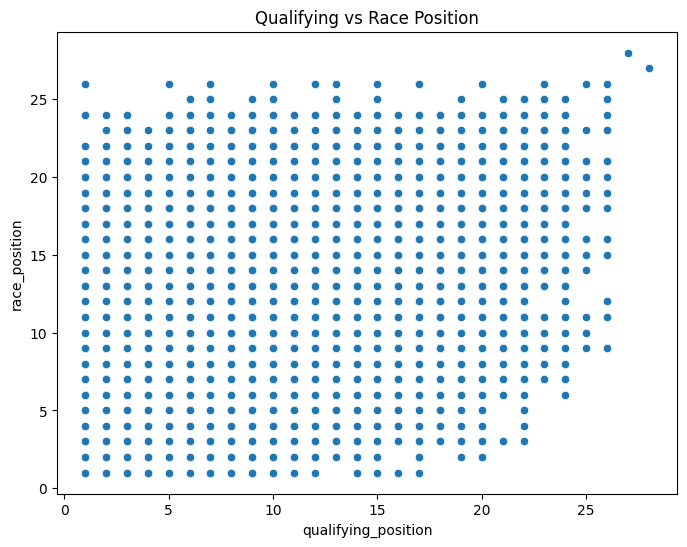

In [8]:
#eda

#does qualifying affect race result
plt.figure(figsize=(8,6))
sns.scatterplot(x='qualifying_position', y='race_position', data=df)
plt.title("Qualifying vs Race Position")
plt.show()

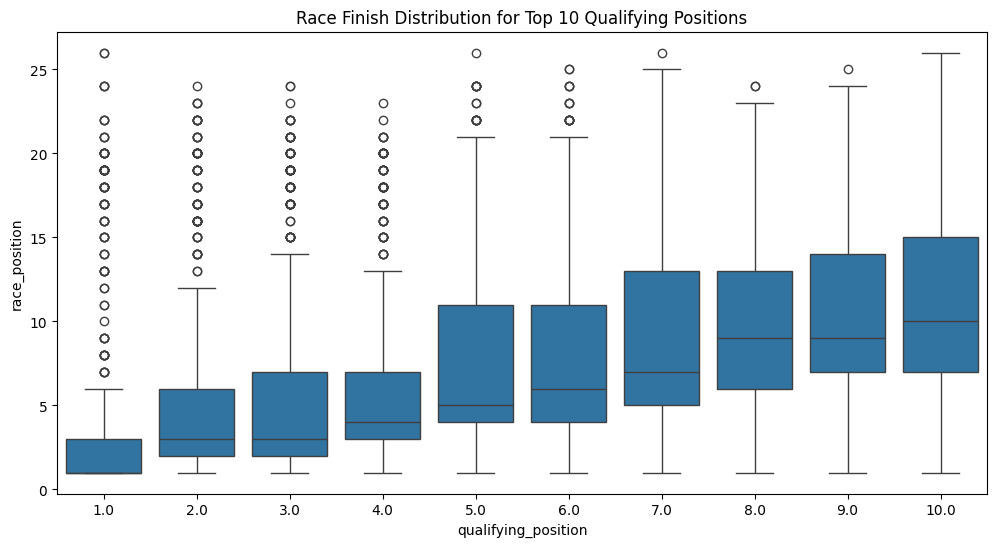

In [9]:
df[['qualifying_position','race_position']].corr()
plt.figure(figsize=(12,6))
sns.boxplot(x='qualifying_position', y='race_position', data=df[df['qualifying_position'] <= 10])
plt.title("Race Finish Distribution for Top 10 Qualifying Positions")
plt.show()

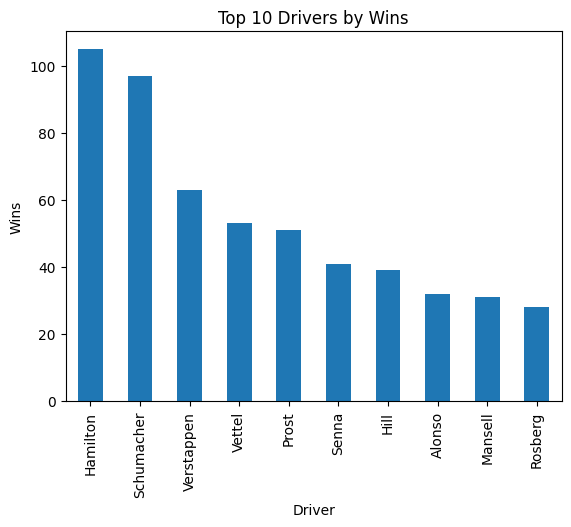

In [10]:
#Top 10 Drivers by Wins
top_wins = df[df['race_position']==1]['surname'].value_counts().head(10)

top_wins.plot(kind='bar')
plt.title("Top 10 Drivers by Wins")
plt.xlabel('Driver')
plt.ylabel('Wins')
plt.show()

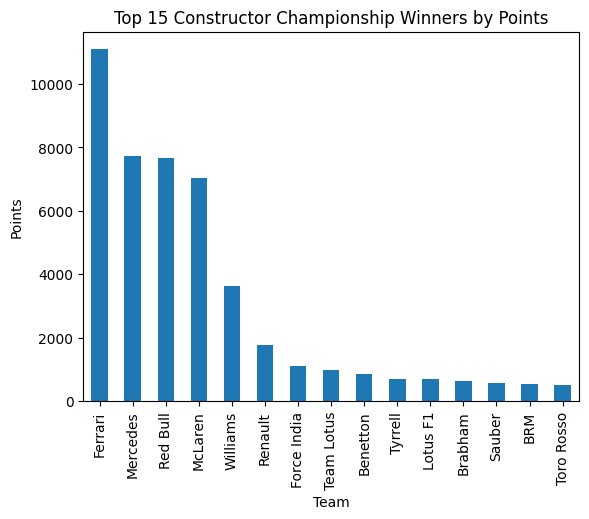

In [11]:
#Constructor Dominance bar
constructor_points = df.groupby('team_name')['points'].sum().sort_values(ascending=False).head(15)

constructor_points.plot(kind='bar')
plt.title("Top 15 Constructor Championship Winners by Points")
plt.xlabel('Team')
plt.ylabel('Points')
plt.show()

<Figure size 1400x800 with 0 Axes>

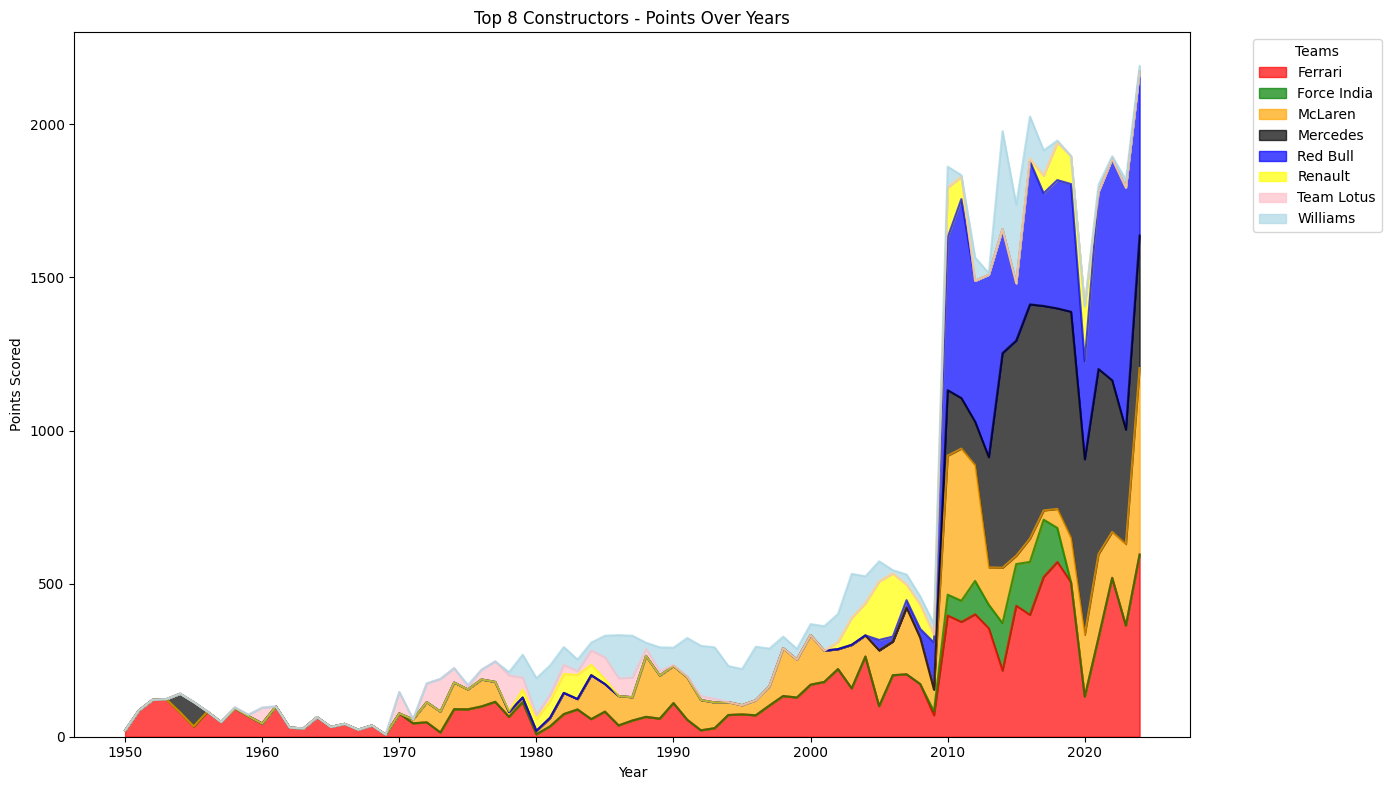

In [12]:
top10_teams=(df.groupby('team_name')['points']
                       .sum()
                       .sort_values(ascending=False)
                       .head(8)
                       .index
                     )
top_df=df[df['team_name'].isin(top10_teams)]

season_points=(top_df.groupby(['year', 'team_name'])['points'].sum().reset_index())

pivot_df=season_points.pivot(
    index='year',
    columns='team_name',
    values='points'
).fillna(0)

plt.figure(figsize=(14,8))

pivot_df.plot(
    kind='area',
    stacked=True,
    figsize=(14,8),
    color=['red','green','orange','black','blue','yellow','pink','lightblue'],
    alpha=0.7
)
plt.title("Top 8 Constructors - Points Over Years")
plt.xlabel("Year")
plt.ylabel("Points Scored")
plt.legend(title="Teams", bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

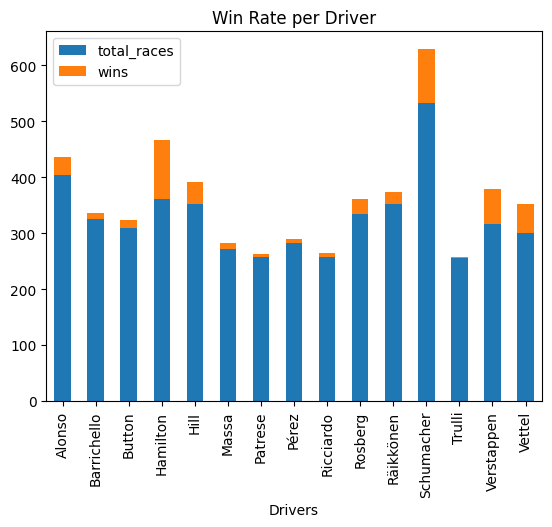

In [16]:
driver_stats = df.groupby('surname').agg(
    total_races=('race_position','count'),
    wins=('is_winner','sum')
)

top_win_rate = driver_stats[driver_stats['total_races'] > 250] 

top_win_rate.plot(kind='bar',stacked=True)
plt.xlabel('Drivers')
plt.title('Win Rate per Driver')
plt.show()

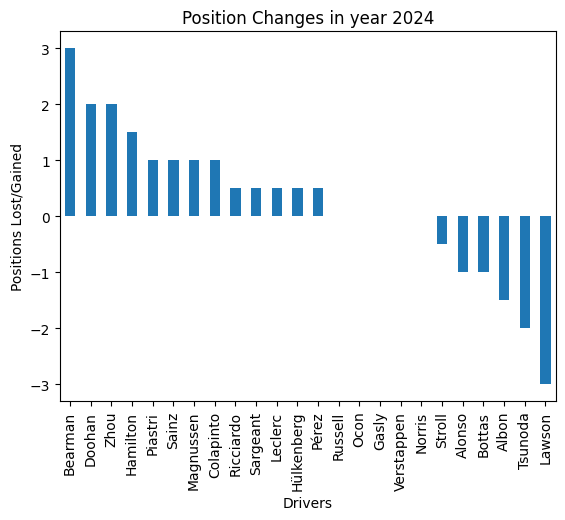

In [17]:
df['position_change'] = df['grid'] - df['race_position']
df=df[df['year']==2024]
best_overtakers = df.groupby('surname')['position_change'] \
                     .median() \
                     .sort_values(ascending=False)

best_overtakers.plot(kind='bar')
plt.title('Position Changes in year 2024')
plt.xlabel('Drivers')
plt.ylabel('Positions Lost/Gained')
plt.show()

In [18]:
#statistical analysis
#H0: Qualifying position does not affect race result
#H1: Qualifying position significantly affects race result

from scipy.stats import pearsonr

corr, p_value = pearsonr(df['qualifying_position'].dropna(),
                         df['race_position'].dropna())

print("Correlation:", corr)
print("P-value:", p_value)
if p_value < 0.05:
    print('Suggests Statistically Significant Relationship in qualifying position and race position.')

Correlation: 0.7454876130037147
P-value: 4.446510933812598e-86
Suggests Statistically Significant Relationship in qualifying position and race position.


In [19]:
model_df=df[['qualifying_position','grid','points','year','is_winner']].dropna()
#train test split
X = model_df.drop('is_winner', axis=1)
y = model_df['is_winner']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
#random forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

pred = rf.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        91
           1       1.00      1.00      1.00         5

    accuracy                           1.00        96
   macro avg       1.00      1.00      1.00        96
weighted avg       1.00      1.00      1.00        96



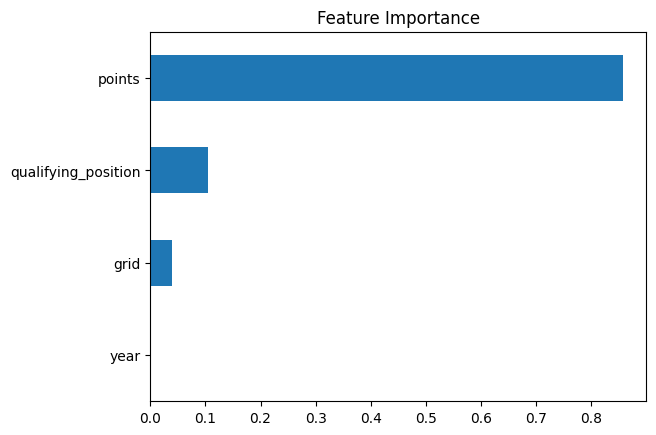

In [21]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [22]:
model_df = df[['qualifying_position','race_position']].copy()

# Drop missing
model_df = model_df.dropna()

# Create winner label
model_df['is_winner'] = (model_df['race_position'] == 1).astype(int)

# Keep only needed columns
model_df = model_df[['qualifying_position','is_winner']]

In [23]:
X = model_df[['qualifying_position']]
y = model_df['is_winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        91
           1       0.00      0.00      0.00         5

    accuracy                           0.95        96
   macro avg       0.47      0.50      0.49        96
weighted avg       0.90      0.95      0.92        96

ROC AUC: 0.878021978021978


D:\python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\python\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


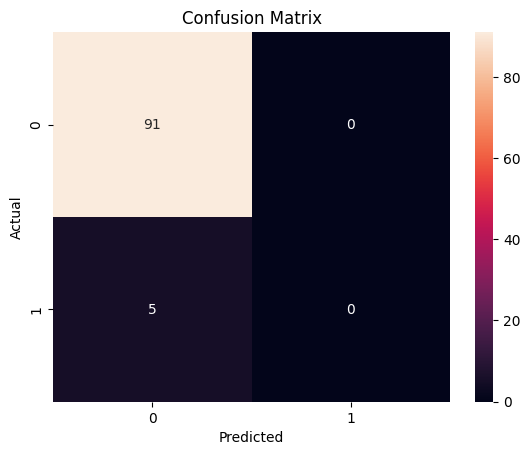

In [24]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

D:\python\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


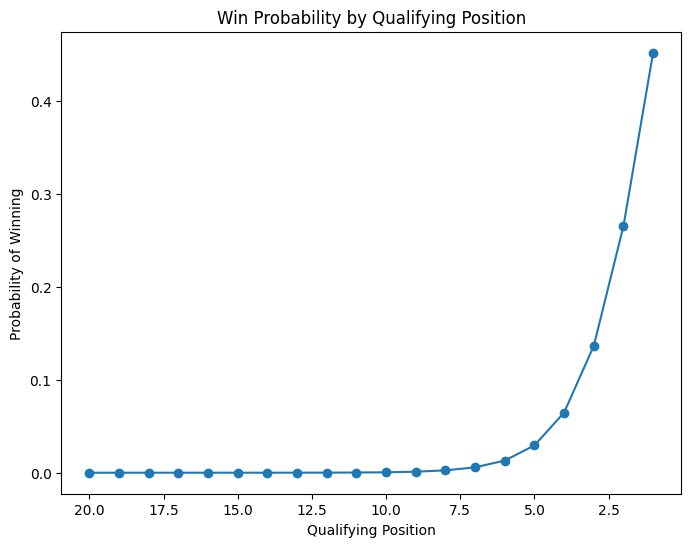

In [25]:
qual_range = np.arange(1,21).reshape(-1,1)
win_prob = log_model.predict_proba(qual_range)[:,1]

plt.figure(figsize=(8,6))
plt.plot(qual_range, win_prob, marker='o')
plt.title("Win Probability by Qualifying Position")
plt.xlabel("Qualifying Position")
plt.ylabel("Probability of Winning")
plt.gca().invert_xaxis()
plt.show()